# Equity and Stock-Bond Linkage Factors

## TL;DR

This report documents the point-in-time construction and quality controls for the equity and stock-bond linkage factor family. All displayed counts, dates, coverage rates, distribution statistics, and rank correlations are read from the existing G3 audit artifacts or factor panel. The report evaluates construction integrity and information overlap only; it does not load an outcome label or assess trading performance.

## Context & Methods

### Glossary

- **Convertible Bond (CB):** a bond that can be converted into the issuer's equity under specified terms.
- **Relative Strength Index (RSI):** the share of positive adjusted price changes in total absolute adjusted price changes over the window.
- **Money Flow Index (MFI):** a directional typical-price and volume measure; it is not a direct measure of investor cash flow.
- **Percent B:** the close's standardized position within Bollinger Bands. It is an indicator name, not an abbreviation.
- **Pearson correlation:** the linear co-movement of paired CB and equity daily returns.
- **Rolling beta:** paired rolling covariance of CB and equity returns divided by equity-return variance.
- **Chinese yuan (CNY):** the currency unit used for transaction amount in the equity illiquidity measure.

### Factor families and economic interpretation

| Family | Construction | Economic interpretation |
|---|---|---|
| Equity trend | Adjusted-close returns over 5, 10, and 20 market days; 20-day RSI; close to 20-day high; 20-day Percent B; 20-day MFI | Direction, persistence, price location, and volume-confirmed trend in the underlying equity |
| Equity risk and liquidity | Annualized 20-day return volatility; 20-day Amihud illiquidity | Equity uncertainty and price movement per unit of traded CNY |
| Stock-bond linkage | CB return minus equity return over 5, 10, and 20 days; Pearson correlation and rolling beta over 20 and 60 days | Relative participation of the CB and the strength of its equity sensitivity |

### Formulas and timing

- Equity return is `adjusted_close_t / adjusted_close_(t-N) - 1`, where adjusted close equals raw close multiplied by the adjustment factor.
- Annualized volatility is the 20-market-day sample standard deviation of daily returns multiplied by the square root of 252.
- RSI is `positive adjusted price change / absolute adjusted price change * 100` over 20 market days.
- Percent B is `(adjusted close - lower band) / (upper band - lower band)`; bands use the 20-day mean plus or minus two population standard deviations.
- Equity Amihud is `mean(abs(daily return) / amount_cny) * 1e8` over 20 market days.
- MFI is `positive directional money flow / total directional money flow * 100` over 20 market days.
- The stock-bond return spread is raw CB close return minus adjusted equity close return for the same window.
- Correlation and beta use only paired CB-equity observations. The 80% minimum-observation rule requires at least 16 paired observations in a 20-day window and 48 in a 60-day window.
- Signals use data available through the signal-date close. Suspended or otherwise unobserved dates remain missing and are never forward-filled.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cb_quant.plotting import configure_matplotlib
from cb_quant.notebook_quality import build_lineage_gate
from cb_quant.stock_linkage import STOCK_LINKAGE_FACTOR_COLUMNS

configure_matplotlib()
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "G3"
ASSET_ROOT = PROJECT_ROOT / "docs" / "assets"
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

panel_files = sorted(
    (ARTIFACT_ROOT / "stock_linkage_factor_panel_v1").glob("year=*/part-*.parquet")
)
assert panel_files, "Stored G3 equity-linkage panel partitions are missing"
panel = pd.concat((pd.read_parquet(path) for path in panel_files), ignore_index=True)
panel["signal_date"] = pd.to_datetime(panel["signal_date"])
audit = json.loads(
    (ARTIFACT_ROOT / "stock_linkage_factor_audit_v1.json").read_text(encoding="utf-8")
)
stage_audit_paths = {
    "G0": PROJECT_ROOT / "artifacts/G0/research_config_validation_v1.json",
    "G1": PROJECT_ROOT / "artifacts/G1/universe_audit_v1.json",
    "G2": PROJECT_ROOT / "artifacts/G2/valuation_factor_audit_v1.json",
    "G3a": PROJECT_ROOT / "artifacts/G3/stock_linkage_factor_audit_v1.json",
    "G3b": PROJECT_ROOT / "artifacts/G3/cb_trading_factor_audit_v1.json",
}
stage_audits = {
    stage: json.loads(path.read_text(encoding="utf-8"))
    for stage, path in stage_audit_paths.items()
}
lineage_gate = build_lineage_gate(stage_audits)
anomaly_review = pd.read_parquet(
    ARTIFACT_ROOT / "stock_linkage_anomaly_review_v1.parquet"
)

FACTOR_LABELS = {
    "stock_return_5d": "Equity return (5d)",
    "stock_return_10d": "Equity return (10d)",
    "stock_return_20d": "Equity return (20d)",
    "stock_volatility_20d": "Equity volatility (20d)",
    "stock_rsi_20d": "Equity RSI (20d)",
    "stock_price_to_high_20d": "Close / high (20d)",
    "stock_percent_b_20d": "Percent B (20d)",
    "stock_amihud_20d": "Equity Amihud (20d)",
    "stock_mfi_20d": "Equity MFI (20d)",
    "cb_stock_return_spread_5d": "CB-equity spread (5d)",
    "cb_stock_return_spread_10d": "CB-equity spread (10d)",
    "cb_stock_return_spread_20d": "CB-equity spread (20d)",
    "cb_stock_correlation_20d": "CB-equity correlation (20d)",
    "cb_stock_correlation_60d": "CB-equity correlation (60d)",
    "cb_stock_beta_20d": "CB-equity beta (20d)",
    "cb_stock_beta_60d": "CB-equity beta (60d)",
}

## Data Quality Gate

The release gate checks exact alignment with the G1 investable keys, unique bond-date observations, independently replicated formulas, the audited factor inventory, point-in-time window coverage, and structural ranges. The anomaly review is loaded as supporting evidence rather than used to change any factor value.

In [2]:
assert audit["status"] == "pass"
assert lineage_gate["status"] == "pass"
assert audit["duplicate_signal_bond_keys"] == 0
assert audit["missing_expected_keys"] == 0
assert audit["extra_unexpected_keys"] == 0
assert audit["formula_mismatch_count"] == 0
assert len(panel) == audit["row_count"]
assert panel["signal_date"].nunique() == audit["signal_date_count"]
assert set(audit["factor_coverage"]) == set(STOCK_LINKAGE_FACTOR_COLUMNS)
assert not panel.duplicated(["signal_date", "ts_code"]).any()

coverage = pd.Series(audit["factor_coverage"], name="Coverage")
quality_summary = pd.DataFrame(
    {
        "Metric": [
            "Audit status",
            "Lineage gate",
            "Panel observations",
            "Signal dates",
            "Factor count",
            "Coverage range",
            "Key mismatches",
            "Formula mismatches",
            "Minimum observation ratio",
            "Anomaly-review rows",
            "Sample period",
        ],
        "Observed value": [
            audit["status"],
            lineage_gate["detail"],
            f"{audit['row_count']:,}",
            f"{audit['signal_date_count']:,}",
            f"{len(audit['factor_coverage']):,}",
            f"{coverage.min():.2%} to {coverage.max():.2%}",
            f"{audit['missing_expected_keys'] + audit['extra_unexpected_keys']:,}",
            f"{audit['formula_mismatch_count']:,}",
            f"{audit['minimum_observation_ratio']:.0%}",
            f"{len(anomaly_review):,}",
            f"{audit['sample_start']} to {audit['sample_end']}",
        ],
    }
)
display(quality_summary)

,Metric,Observed value
0,Audit status,pass
1,Lineage gate,Stored stage configuration fingerprints match.
2,Panel observations,"44,728"
3,Signal dates,222
4,Factor count,16
5,Coverage range,95.65% to 99.92%
6,Key mismatches,0
7,Formula mismatches,0
8,Minimum observation ratio,80%
9,Anomaly-review rows,320


## Results

Coverage is shown on its full observed comparison range. The correlation panel uses the complete `[-1, 1]` color scale so weak and strong relationships remain comparable. Distribution statistics come from stored audit quantiles; no values are winsorized or removed for this report.

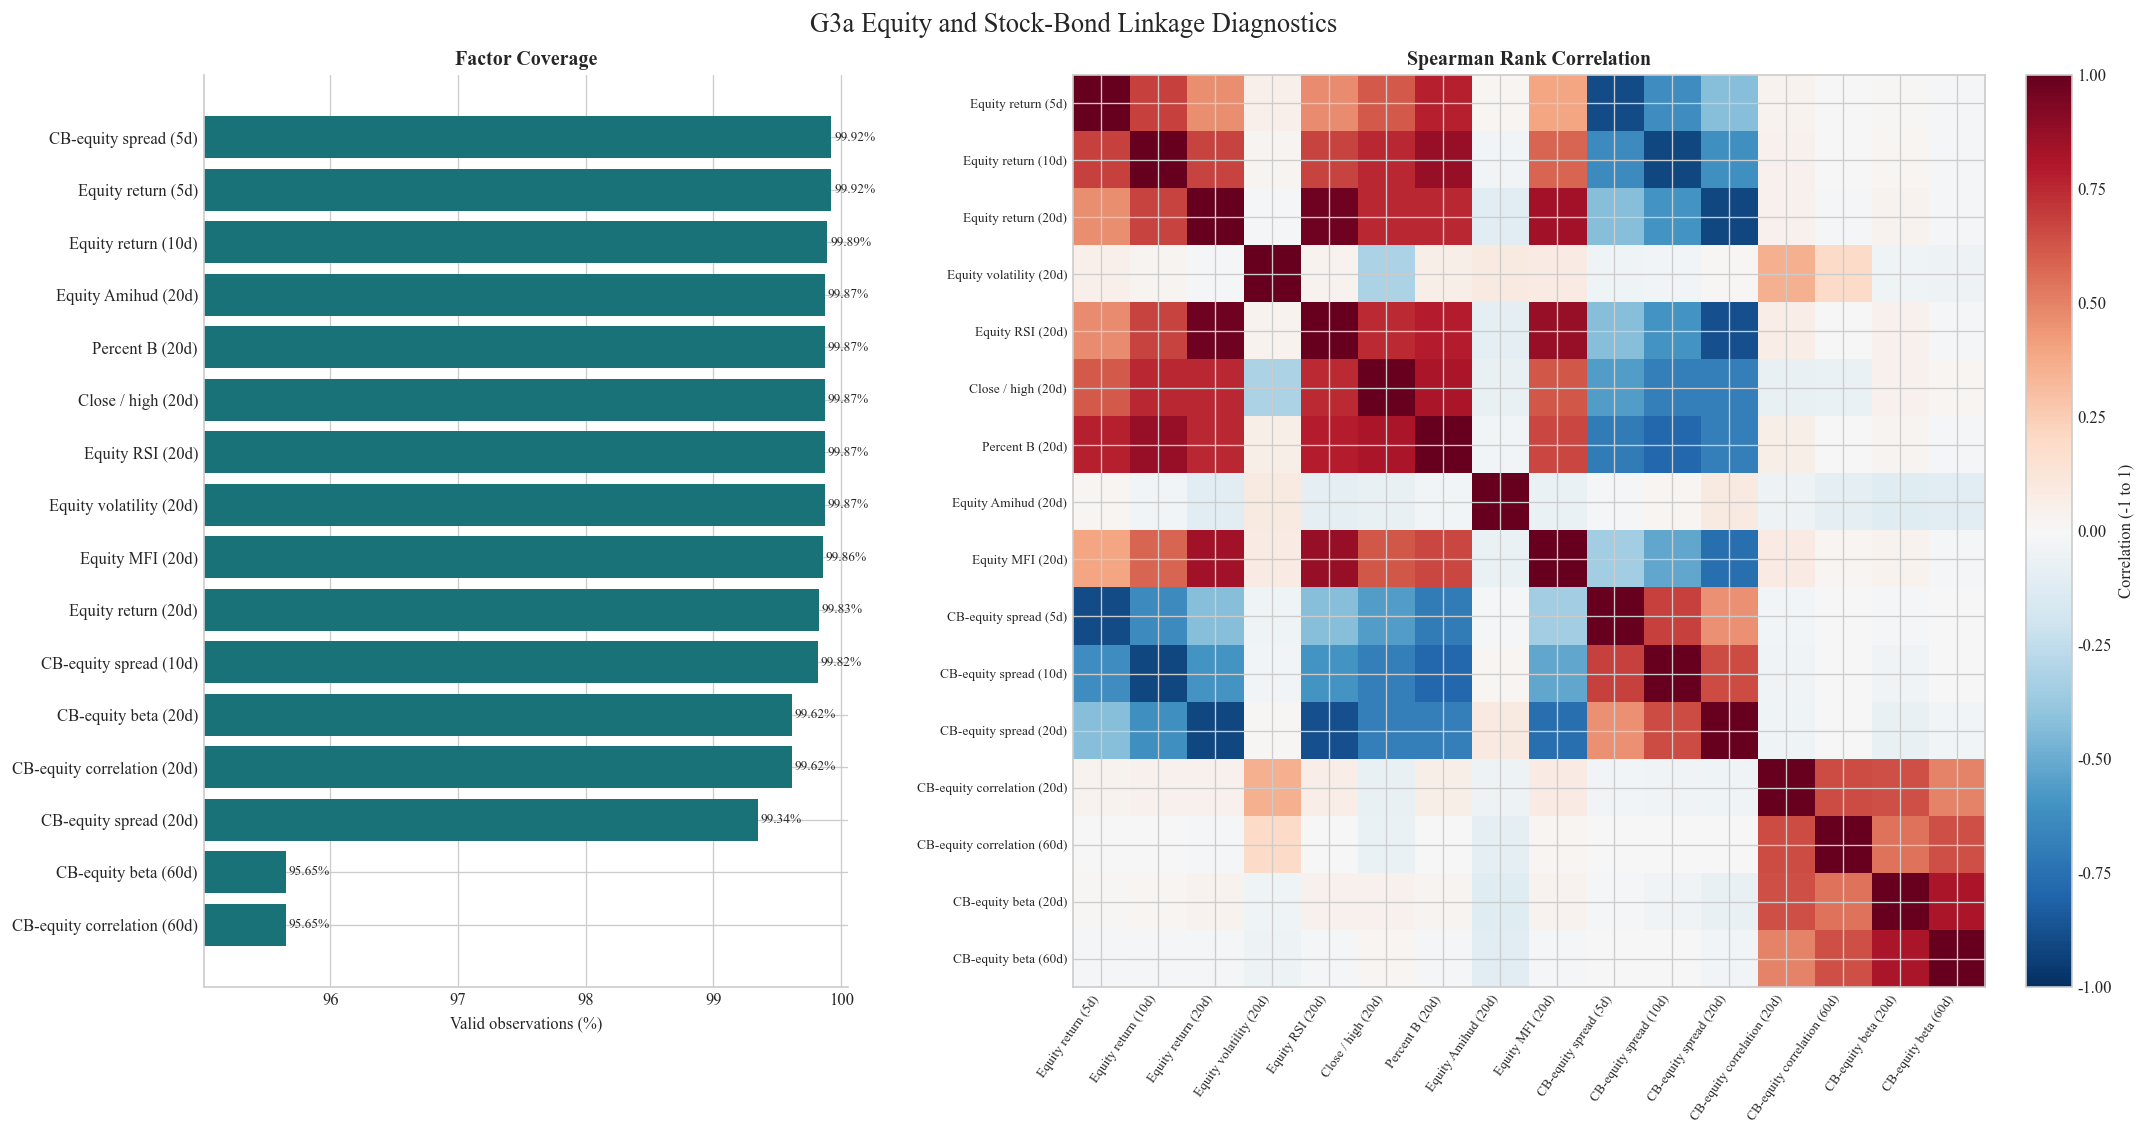

In [3]:
coverage = coverage.reindex(STOCK_LINKAGE_FACTOR_COLUMNS).sort_values()
correlation = pd.DataFrame(audit["factor_spearman_correlation"]).loc[
    STOCK_LINKAGE_FACTOR_COLUMNS, STOCK_LINKAGE_FACTOR_COLUMNS
]

fig, axes = plt.subplots(1, 2, figsize=(18, 9.5), gridspec_kw={"width_ratios": [0.85, 1.35]})

coverage_values = coverage * 100
axes[0].barh(
    [FACTOR_LABELS[factor] for factor in coverage.index],
    coverage_values,
    color="#197278",
)
coverage_margin = max(0.15, (coverage_values.max() - coverage_values.min()) * 0.15)
axes[0].set_xlim(coverage_values.min() - coverage_margin, 100.05)
axes[0].set_xlabel("Valid observations (%)")
axes[0].set_title("Factor Coverage")
for row, value in enumerate(coverage_values):
    axes[0].text(value + 0.02, row, f"{value:.2f}%", va="center", fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

labels = [FACTOR_LABELS[factor] for factor in STOCK_LINKAGE_FACTOR_COLUMNS]
image = axes[1].imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(labels)), labels=labels, rotation=55, ha="right", fontsize=8)
axes[1].set_yticks(range(len(labels)), labels=labels, fontsize=8)
axes[1].set_title("Spearman Rank Correlation")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label="Correlation (-1 to 1)")

fig.suptitle("G3a Equity and Stock-Bond Linkage Diagnostics", fontsize=16)
fig.tight_layout()
asset_path = ASSET_ROOT / "g3a_equity_linkage_diagnostics.png"
fig.savefig(asset_path, dpi=140, bbox_inches="tight")
plt.show()

In [4]:
distribution_summary = (
    pd.DataFrame(audit["factor_quantiles"])
    .T[["0.01", "0.05", "0.5", "0.95", "0.99"]]
    .rename(index=FACTOR_LABELS)
    .rename(columns={"0.01": "P01", "0.05": "P05", "0.5": "Median", "0.95": "P95", "0.99": "P99"})
)

pairs = []
for left_index, left in enumerate(STOCK_LINKAGE_FACTOR_COLUMNS):
    for right in STOCK_LINKAGE_FACTOR_COLUMNS[left_index + 1:]:
        value = correlation.loc[left, right]
        pairs.append(
            {
                "Factor A": FACTOR_LABELS[left],
                "Factor B": FACTOR_LABELS[right],
                "Spearman correlation": value,
                "Absolute correlation": abs(value),
            }
        )
rank_overlap = (
    pd.DataFrame(pairs)
    .sort_values("Absolute correlation", ascending=False)
    .head(8)
    .drop(columns="Absolute correlation")
)

display(distribution_summary.style.format("{:.4f}"))
display(rank_overlap.style.format({"Spearman correlation": "{:.3f}"}))

,P01,P05,Median,P95,P99
Equity return (5d),-0.1343,-0.0792,-0.0016,0.0852,0.1577
Equity return (10d),-0.1857,-0.1151,-0.0047,0.1142,0.2125
Equity return (20d),-0.2398,-0.1598,-0.0135,0.1529,0.2827
Equity volatility (20d),0.1054,0.1449,0.3090,0.6092,0.8018
Equity RSI (20d),17.2798,25.0000,47.4522,70.2703,79.1742
Close / high (20d),0.7513,0.8264,0.9515,1.0000,1.0000
Percent B (20d),-0.1565,-0.0322,0.4503,1.0083,1.1767
Equity Amihud (20d),0.0009,0.0024,0.0190,0.0927,0.1541
Equity MFI (20d),19.0302,26.9063,51.2201,73.4335,80.9863
CB-equity spread (5d),-0.1208,-0.0616,0.0016,0.0625,0.1064


,Factor A,Factor B,Spearman correlation
30,Equity return (20d),Equity RSI (20d),0.970
37,Equity return (20d),CB-equity spread (20d),-0.911
23,Equity return (10d),CB-equity spread (10d),-0.908
8,Equity return (5d),CB-equity spread (5d),-0.893
60,Equity RSI (20d),CB-equity spread (20d),-0.882
19,Equity return (10d),Percent B (20d),0.873
57,Equity RSI (20d),Equity MFI (20d),0.870
34,Equity return (20d),Equity MFI (20d),0.839


## Takeaways

1. The stored panel, investable keys, and independently replicated formulas pass the documented quality gate.
2. Coverage remains high across short and long point-in-time windows; missing values are retained where histories are incomplete or paired observations are unavailable.
3. Equity trend indicators and stock-bond linkage measures contain visible rank overlap. That overlap is a feature-engineering consideration, not evidence of economic efficacy.
4. Correlation and beta describe different aspects of linkage: direction consistency versus return sensitivity.
5. This stage freezes transparent raw definitions. Scaling, outlier handling, and combination rules belong to a later preprocessing stage.